In [261]:
import pandas as pd

In [262]:
# Read the Excel file
excel_file = "Book1.xlsx"  # Replace with your file path
dfx = pd.read_excel(excel_file)

# Convert to CSV
csv_file = "output.csv"  # Replace with your desired output path # Understand-> dfx holding excel data, .to_csv converting this excel to csv, store as csv_file which is a variable for output.csv, hence output.csv will be downloaded 
dfx.to_csv(csv_file, index=False)  # index=False prevents adding row numbers

print(f"Successfully converted {excel_file} to {csv_file}")

Successfully converted Book1.xlsx to output.csv


In [263]:
# For a specific sheet
# df = pd.read_excel(excel_file, sheet_name="Sheet2")
# df.to_csv(f"output_sheet2.csv", index=False)

In [264]:
# output .csv want to store in df

df = pd.read_csv("output.csv")

In [265]:
# to see structure of data 
df.head()   

,company,year,total_revenue,net_income,total_assets,total_liabilities,cash_flow_from_operating_activities
0,Microsoft,2025.0,281724.0,101832.0,619003.0,275524.0,136162.0
1,Microsoft,2024.0,245122.0,88136.0,512163.0,243686.0,118548.0
2,Microsoft,2023.0,211915.0,72361.0,411976.0,205753.0,87582.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Tesla,2025.0,94827.0,3855.0,137806.0,54941.0,14747.0


In [266]:
#noted: i can see NaN value: we will deal with it later.
#noted: year in float64, it should be integer..later dea.

In [267]:
# general information about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   company                              9 non-null      object 
 1   year                                 9 non-null      float64
 2   total_revenue                        9 non-null      float64
 3   net_income                           9 non-null      float64
 4   total_assets                         9 non-null      float64
 5   total_liabilities                    9 non-null      float64
 6   cash_flow_from_operating_activities  9 non-null      float64
dtypes: float64(6), object(1)
memory usage: 748.0+ bytes


In [268]:
# Check for missing values or NaN 
df.isnull().sum()

company                                2
year                                   2
total_revenue                          2
net_income                             2
total_assets                           2
total_liabilities                      2
cash_flow_from_operating_activities    2
dtype: int64

In [269]:
df

,company,year,total_revenue,net_income,total_assets,total_liabilities,cash_flow_from_operating_activities
0,Microsoft,2025.0,281724.0,101832.0,619003.0,275524.0,136162.0
1,Microsoft,2024.0,245122.0,88136.0,512163.0,243686.0,118548.0
2,Microsoft,2023.0,211915.0,72361.0,411976.0,205753.0,87582.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Tesla,2025.0,94827.0,3855.0,137806.0,54941.0,14747.0
5,Tesla,2024.0,97690.0,7153.0,122070.0,48390.0,14923.0
6,Tesla,2023.0,96773.0,14974.0,106618.0,43009.0,13256.0
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Apple,2025.0,416161.0,112010.0,359241.0,285508.0,111482.0
9,Apple,2024.0,391035.0,93736.0,364980.0,308030.0,118254.0


In [270]:
# drop rows with any NaN

df.dropna(inplace=True)

In [271]:
df

,company,year,total_revenue,net_income,total_assets,total_liabilities,cash_flow_from_operating_activities
0,Microsoft,2025.0,281724.0,101832.0,619003.0,275524.0,136162.0
1,Microsoft,2024.0,245122.0,88136.0,512163.0,243686.0,118548.0
2,Microsoft,2023.0,211915.0,72361.0,411976.0,205753.0,87582.0
4,Tesla,2025.0,94827.0,3855.0,137806.0,54941.0,14747.0
5,Tesla,2024.0,97690.0,7153.0,122070.0,48390.0,14923.0
6,Tesla,2023.0,96773.0,14974.0,106618.0,43009.0,13256.0
8,Apple,2025.0,416161.0,112010.0,359241.0,285508.0,111482.0
9,Apple,2024.0,391035.0,93736.0,364980.0,308030.0,118254.0
10,Apple,2023.0,383285.0,96995.0,352583.0,290437.0,110543.0


In [272]:
# year -> int
df["year"] = df["year"].astype(int)

In [273]:
# Growth always flows: Past → Present → Future
# pct_change compares each row with the previous row, so data must be ordered chronologically.

df = df.sort_values(["company", "year"])

### eg. sorting will be like : A-Z and chronological order (important for "growth calculation") 
#Microsoft:
#2023
#2024
#2025

In [274]:
df

,company,year,total_revenue,net_income,total_assets,total_liabilities,cash_flow_from_operating_activities
10,Apple,2023,383285.0,96995.0,352583.0,290437.0,110543.0
9,Apple,2024,391035.0,93736.0,364980.0,308030.0,118254.0
8,Apple,2025,416161.0,112010.0,359241.0,285508.0,111482.0
2,Microsoft,2023,211915.0,72361.0,411976.0,205753.0,87582.0
1,Microsoft,2024,245122.0,88136.0,512163.0,243686.0,118548.0
0,Microsoft,2025,281724.0,101832.0,619003.0,275524.0,136162.0
6,Tesla,2023,96773.0,14974.0,106618.0,43009.0,13256.0
5,Tesla,2024,97690.0,7153.0,122070.0,48390.0,14923.0
4,Tesla,2025,94827.0,3855.0,137806.0,54941.0,14747.0


In [275]:
# serial number looking abrupt:

df = df.reset_index(drop=True)


In [276]:
df

,company,year,total_revenue,net_income,total_assets,total_liabilities,cash_flow_from_operating_activities
0,Apple,2023,383285.0,96995.0,352583.0,290437.0,110543.0
1,Apple,2024,391035.0,93736.0,364980.0,308030.0,118254.0
2,Apple,2025,416161.0,112010.0,359241.0,285508.0,111482.0
3,Microsoft,2023,211915.0,72361.0,411976.0,205753.0,87582.0
4,Microsoft,2024,245122.0,88136.0,512163.0,243686.0,118548.0
5,Microsoft,2025,281724.0,101832.0,619003.0,275524.0,136162.0
6,Tesla,2023,96773.0,14974.0,106618.0,43009.0,13256.0
7,Tesla,2024,97690.0,7153.0,122070.0,48390.0,14923.0
8,Tesla,2025,94827.0,3855.0,137806.0,54941.0,14747.0


In [277]:
# Now, calculate revenue growth

df["Revenue Growth (%)"] = (
    df.groupby("company")["total_revenue"].pct_change() * 100
)

In [278]:
df

,company,year,total_revenue,net_income,total_assets,total_liabilities,cash_flow_from_operating_activities,Revenue Growth (%)
0,Apple,2023,383285.0,96995.0,352583.0,290437.0,110543.0,NaN
1,Apple,2024,391035.0,93736.0,364980.0,308030.0,118254.0,2.021994
2,Apple,2025,416161.0,112010.0,359241.0,285508.0,111482.0,6.425512
3,Microsoft,2023,211915.0,72361.0,411976.0,205753.0,87582.0,NaN
4,Microsoft,2024,245122.0,88136.0,512163.0,243686.0,118548.0,15.669962
5,Microsoft,2025,281724.0,101832.0,619003.0,275524.0,136162.0,14.932156
6,Tesla,2023,96773.0,14974.0,106618.0,43009.0,13256.0,NaN
7,Tesla,2024,97690.0,7153.0,122070.0,48390.0,14923.0,0.947578
8,Tesla,2025,94827.0,3855.0,137806.0,54941.0,14747.0,-2.930699


In [279]:
# Net income growth pct

df["Net Income Growth (%)"] = (
    df.groupby("company")["net_income"].pct_change() * 100
)

In [280]:
df

,company,year,total_revenue,net_income,total_assets,total_liabilities,cash_flow_from_operating_activities,Revenue Growth (%),Net Income Growth (%)
0,Apple,2023,383285.0,96995.0,352583.0,290437.0,110543.0,NaN,NaN
1,Apple,2024,391035.0,93736.0,364980.0,308030.0,118254.0,2.021994,-3.359967
2,Apple,2025,416161.0,112010.0,359241.0,285508.0,111482.0,6.425512,19.495178
3,Microsoft,2023,211915.0,72361.0,411976.0,205753.0,87582.0,NaN,NaN
4,Microsoft,2024,245122.0,88136.0,512163.0,243686.0,118548.0,15.669962,21.800417
5,Microsoft,2025,281724.0,101832.0,619003.0,275524.0,136162.0,14.932156,15.539621
6,Tesla,2023,96773.0,14974.0,106618.0,43009.0,13256.0,NaN,NaN
7,Tesla,2024,97690.0,7153.0,122070.0,48390.0,14923.0,0.947578,-52.230533
8,Tesla,2025,94827.0,3855.0,137806.0,54941.0,14747.0,-2.930699,-46.106529


In [281]:
# Debt Ratio -> Risk check metric

df["Debt ratio"] = (
    df["total_liabilities"] / df["total_assets"]
)


# groupby("company")....not taken cz earlier calculations based on comparision of different rows
# but in debt ratio -> comparision or calculation is within single row...

In [282]:
df

,company,year,total_revenue,net_income,total_assets,total_liabilities,cash_flow_from_operating_activities,Revenue Growth (%),Net Income Growth (%),Debt ratio
0,Apple,2023,383285.0,96995.0,352583.0,290437.0,110543.0,NaN,NaN,0.823741
1,Apple,2024,391035.0,93736.0,364980.0,308030.0,118254.0,2.021994,-3.359967,0.843964
2,Apple,2025,416161.0,112010.0,359241.0,285508.0,111482.0,6.425512,19.495178,0.794753
3,Microsoft,2023,211915.0,72361.0,411976.0,205753.0,87582.0,NaN,NaN,0.499430
4,Microsoft,2024,245122.0,88136.0,512163.0,243686.0,118548.0,15.669962,21.800417,0.475798
5,Microsoft,2025,281724.0,101832.0,619003.0,275524.0,136162.0,14.932156,15.539621,0.445109
6,Tesla,2023,96773.0,14974.0,106618.0,43009.0,13256.0,NaN,NaN,0.403393
7,Tesla,2024,97690.0,7153.0,122070.0,48390.0,14923.0,0.947578,-52.230533,0.396412
8,Tesla,2025,94827.0,3855.0,137806.0,54941.0,14747.0,-2.930699,-46.106529,0.398684


In [283]:
# Profit margin : is a Key Performance Indicator...why?
# controls pricing power, sustainability, competitiveness, and long‑term survival


# 1. Two companies may earn the same revenue, but the one with the higher margin keeps more money after costs.
# It reflects: cost control, pricing strategy, operational efficiency
# A business with thin margins is always one shock away from losses.

# 2. High margins usually mean: customers are willing to pay more, the company has a strong brand or unique product, low competitive pressure
# Low margins often indicate: heavy competition, commoditized products, discount‑driven sales

# 3.  strong margins can: survive downturns, invest in innovation, pay employees better, expand into new markets
# influences valuation: higher stock valuations, stronger cash flows, better investor confidence
# Companies with consistently high margins are valued like premium assets.

# 4. Investors look at margins to judge: risk, return potential, management quality
# --> Banks use margins to assess:creditworthiness, ability to repay loans

# 5. It helps compare companies across industries: (V.IMP. factor)

# Profit margin "normalizes performance".
# Even if two companies have different sizes, you can compare them using:

# * Gross margin → production efficiency

# * Operating margin → business model strength

# * Net margin → overall profitability


df["Profit Margin (%)"] = (
    df["net_income"] / df["total_revenue"]
) * 100



In [284]:
df

,company,year,total_revenue,net_income,total_assets,total_liabilities,cash_flow_from_operating_activities,Revenue Growth (%),Net Income Growth (%),Debt ratio,Profit Margin (%)
0,Apple,2023,383285.0,96995.0,352583.0,290437.0,110543.0,NaN,NaN,0.823741,25.306234
1,Apple,2024,391035.0,93736.0,364980.0,308030.0,118254.0,2.021994,-3.359967,0.843964,23.971256
2,Apple,2025,416161.0,112010.0,359241.0,285508.0,111482.0,6.425512,19.495178,0.794753,26.915064
3,Microsoft,2023,211915.0,72361.0,411976.0,205753.0,87582.0,NaN,NaN,0.499430,34.146238
4,Microsoft,2024,245122.0,88136.0,512163.0,243686.0,118548.0,15.669962,21.800417,0.475798,35.955973
5,Microsoft,2025,281724.0,101832.0,619003.0,275524.0,136162.0,14.932156,15.539621,0.445109,36.146015
6,Tesla,2023,96773.0,14974.0,106618.0,43009.0,13256.0,NaN,NaN,0.403393,15.473324
7,Tesla,2024,97690.0,7153.0,122070.0,48390.0,14923.0,0.947578,-52.230533,0.396412,7.322141
8,Tesla,2025,94827.0,3855.0,137806.0,54941.0,14747.0,-2.930699,-46.106529,0.398684,4.065298


In [285]:
# Operating Cash Flow Margin

df["Operating CF margin (%)"] = (
    df["cash_flow_from_operating_activities"] / df["total_revenue"]
) * 100

In [286]:
df

,company,year,total_revenue,net_income,total_assets,total_liabilities,cash_flow_from_operating_activities,Revenue Growth (%),Net Income Growth (%),Debt ratio,Profit Margin (%),Operating CF margin (%)
0,Apple,2023,383285.0,96995.0,352583.0,290437.0,110543.0,NaN,NaN,0.823741,25.306234,28.840941
1,Apple,2024,391035.0,93736.0,364980.0,308030.0,118254.0,2.021994,-3.359967,0.843964,23.971256,30.241283
2,Apple,2025,416161.0,112010.0,359241.0,285508.0,111482.0,6.425512,19.495178,0.794753,26.915064,26.788190
3,Microsoft,2023,211915.0,72361.0,411976.0,205753.0,87582.0,NaN,NaN,0.499430,34.146238,41.328835
4,Microsoft,2024,245122.0,88136.0,512163.0,243686.0,118548.0,15.669962,21.800417,0.475798,35.955973,48.362856
5,Microsoft,2025,281724.0,101832.0,619003.0,275524.0,136162.0,14.932156,15.539621,0.445109,36.146015,48.331701
6,Tesla,2023,96773.0,14974.0,106618.0,43009.0,13256.0,NaN,NaN,0.403393,15.473324,13.698036
7,Tesla,2024,97690.0,7153.0,122070.0,48390.0,14923.0,0.947578,-52.230533,0.396412,7.322141,15.275873
8,Tesla,2025,94827.0,3855.0,137806.0,54941.0,14747.0,-2.930699,-46.106529,0.398684,4.065298,15.551478


In [287]:
# Asset Growth....its a growth (pct_change)...different rows compared...so .groupby

df["Asset Growth (%)"] = (
    df.groupby("company")["total_assets"] . pct_change() * 100
)

In [288]:
df

,company,year,total_revenue,net_income,total_assets,total_liabilities,cash_flow_from_operating_activities,Revenue Growth (%),Net Income Growth (%),Debt ratio,Profit Margin (%),Operating CF margin (%),Asset Growth (%)
0,Apple,2023,383285.0,96995.0,352583.0,290437.0,110543.0,NaN,NaN,0.823741,25.306234,28.840941,NaN
1,Apple,2024,391035.0,93736.0,364980.0,308030.0,118254.0,2.021994,-3.359967,0.843964,23.971256,30.241283,3.516052
2,Apple,2025,416161.0,112010.0,359241.0,285508.0,111482.0,6.425512,19.495178,0.794753,26.915064,26.788190,-1.572415
3,Microsoft,2023,211915.0,72361.0,411976.0,205753.0,87582.0,NaN,NaN,0.499430,34.146238,41.328835,NaN
4,Microsoft,2024,245122.0,88136.0,512163.0,243686.0,118548.0,15.669962,21.800417,0.475798,35.955973,48.362856,24.318650
5,Microsoft,2025,281724.0,101832.0,619003.0,275524.0,136162.0,14.932156,15.539621,0.445109,36.146015,48.331701,20.860546
6,Tesla,2023,96773.0,14974.0,106618.0,43009.0,13256.0,NaN,NaN,0.403393,15.473324,13.698036,NaN
7,Tesla,2024,97690.0,7153.0,122070.0,48390.0,14923.0,0.947578,-52.230533,0.396412,7.322141,15.275873,14.492862
8,Tesla,2025,94827.0,3855.0,137806.0,54941.0,14747.0,-2.930699,-46.106529,0.398684,4.065298,15.551478,12.890964


In [289]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

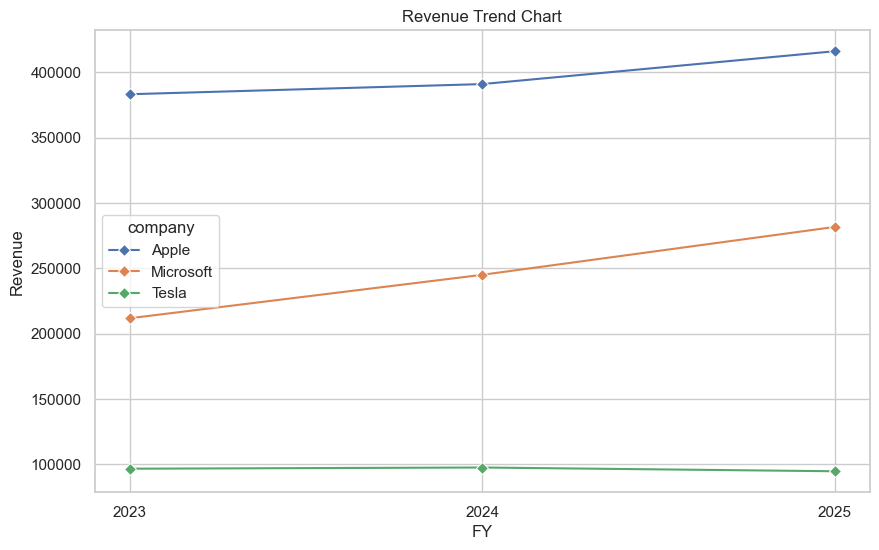

In [290]:
# Revenue Trend Chart

plt.figure(figsize=(10,6))

sns.lineplot(
    data = df,
    x = "year", y = "total_revenue",
    hue = "company",
    marker = "D"   
)


plt.title("Revenue Trend Chart")
plt.xlabel("FY")
plt.xticks([2023, 2024, 2025])
plt.ylabel("Revenue")
plt.show()

# Microsoft is expanding the fastest, showing a sharp revenue climb driven.
# Apple continues to rise steadily. 
# Tesla, however, stays flat and then dips slightly. 
# Final: Microsoft and Apple growing, Tesla losing pace.

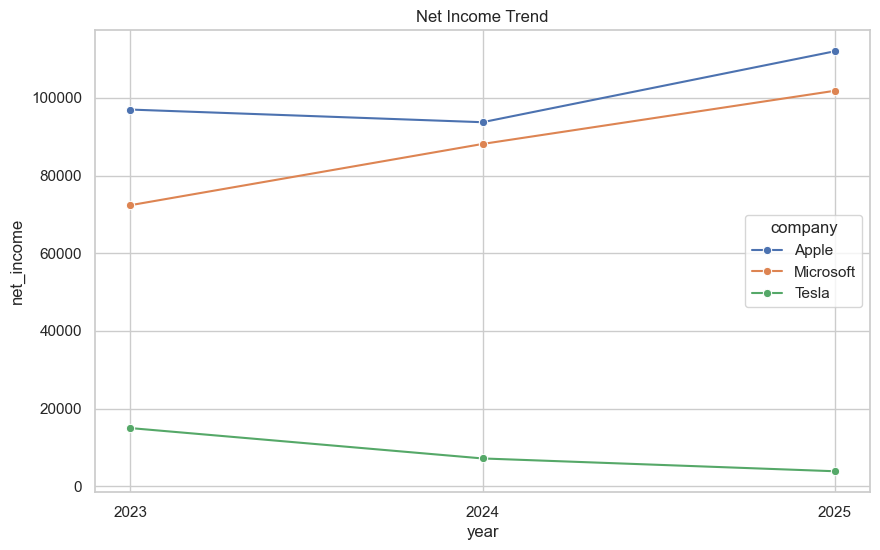

In [291]:
# Profit Comparison Chart : Net income is PAT -> Profit After Tax ( incl. Dep, Amort. and interest)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x="year",
    y="net_income",
    hue="company",
    marker="o"   # not zero, alphabetical o -> create circle
)

plt.title("Net Income Trend")
plt.xticks([2023, 2024, 2025])
plt.show()


# Microsoft shows the strongest and most consistent rise in net income, signaling solid operational efficiency and expanding high‑margin businesses. 
# Apple dips slightly in 2024 but rebounds sharply in 2025, suggesting a temporary slowdown followed by renewed profitability. 
# Tesla, however, declines every year, indicating shrinking margins, rising costs, or weakening demand. 
# The overall picture shows Microsoft and Apple strengthening, while Tesla’s profitability is eroding year after year.

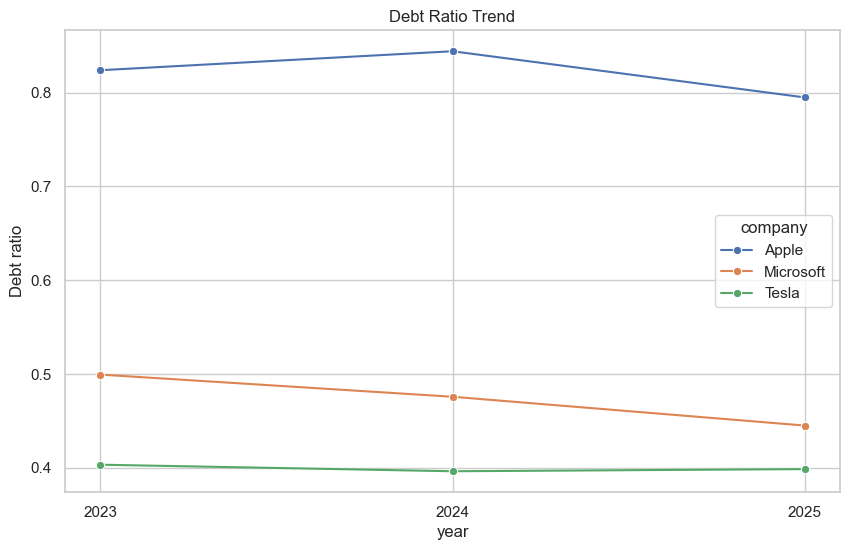

In [292]:
# Debt Ratio Comparison -> t.liab/t.assets

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x="year",
    y="Debt ratio",
    hue="company",
    marker="o"
)

plt.title("Debt Ratio Trend")
plt.xticks([2023, 2024, 2025])
plt.show()


# Microsoft’s debt ratio steadily declines across all three years, showing stronger financial stability. 
# Apple stays high but begins easing down in 2025, suggesting gradual deleveraging after a period of heavier borrowing. 
# Tesla remains the lowest and mostly flat, indicating a "conservative debt structure" but limited change in strategy. 
# Overall, Microsoft is clearly strengthening its financial risk profile, Apple is stabilizing, and Tesla is maintaining a steady but cautious debt position.

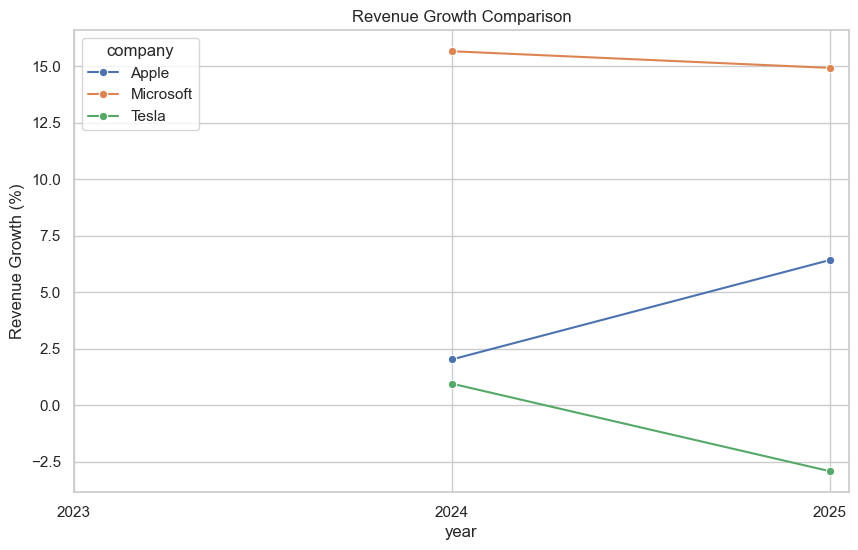

In [293]:
# Revenue Growth Chart

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x="year",
    y="Revenue Growth (%)",
    hue="company",
    marker="o"
)

plt.title("Revenue Growth Comparison")
plt.xticks([2023, 2024, 2025])
plt.show()

Microsoft continues to post the strongest revenue growth, even though it dips slightly, showing it’s still expanding at a high pace.
Apple accelerates from a modest growth rate to a much stronger one, signaling renewed momentum in 2025. 
Tesla moves in the opposite direction, slipping from low growth into negative territory, which reflects weakening demand or operational challenges. 
The overall picture shows Microsoft and Apple growing, while Tesla shifts into contraction.

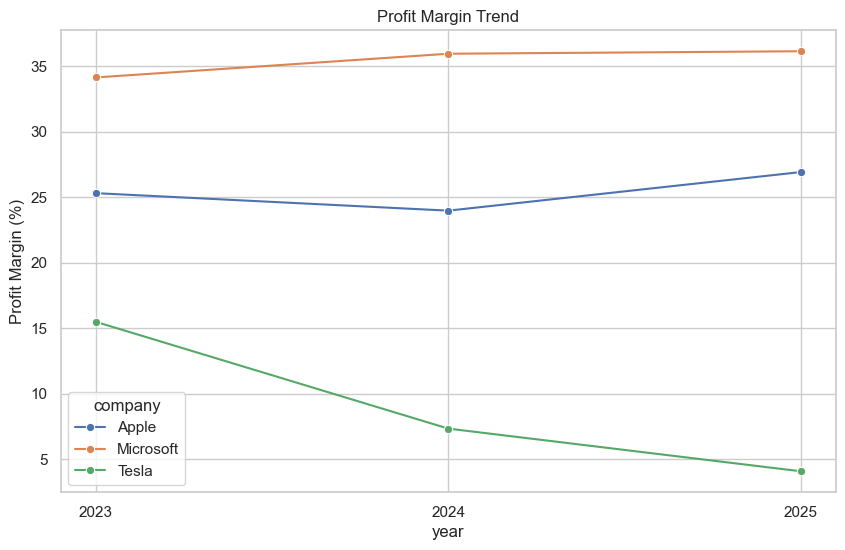

In [294]:
# Profit Margin Chart

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x="year",
    y="Profit Margin (%)",
    hue="company",
    marker="o"
)

plt.title("Profit Margin Trend")
plt.xticks([2023, 2024, 2025])
plt.show()

Microsoft maintains the strongest profit margins, rising and then holding steady at a high level, showing excellent cost control and pricing power. 
Apple dips slightly in 2024 but rebounds in 2025, reflecting a temporary slowdown followed by improved efficiency. 
Tesla’s margins fall consistently, signaling rising costs, competitive pressure, or weaker pricing strength. 
-> The overall pattern shows Microsoft and Apple strengthening profitability, while Tesla’s margins erode year after year.

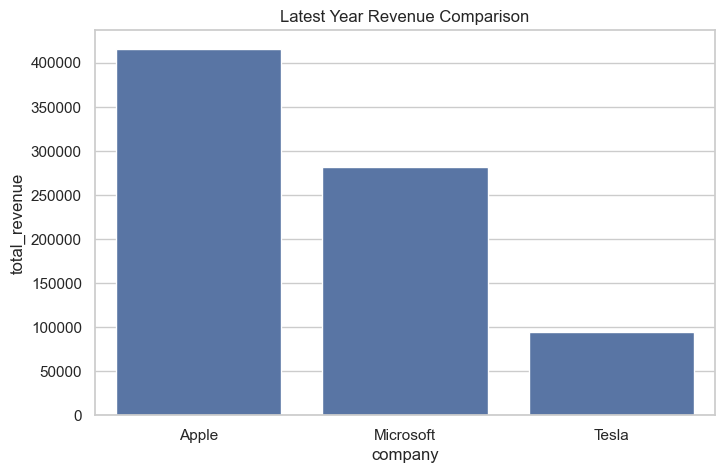

In [295]:
# Comparison Bar Chart

latest = df[df["year"] == df["year"].max()]

plt.figure(figsize=(8,5))

sns.barplot(
    data=latest,
    x="company",
    y="total_revenue"
)

plt.title("Latest Year Revenue Comparison")
plt.show()

Apple clearly leads in total revenue, standing well above Microsoft and far ahead of Tesla. 
Microsoft holds a strong second position, showing solid scale but still noticeably below Apple’s level. 
Tesla remains much smaller in comparison. 
The chart makes the revenue hierarchy very clear: Apple dominates, Microsoft follows, and Tesla trails significantly.

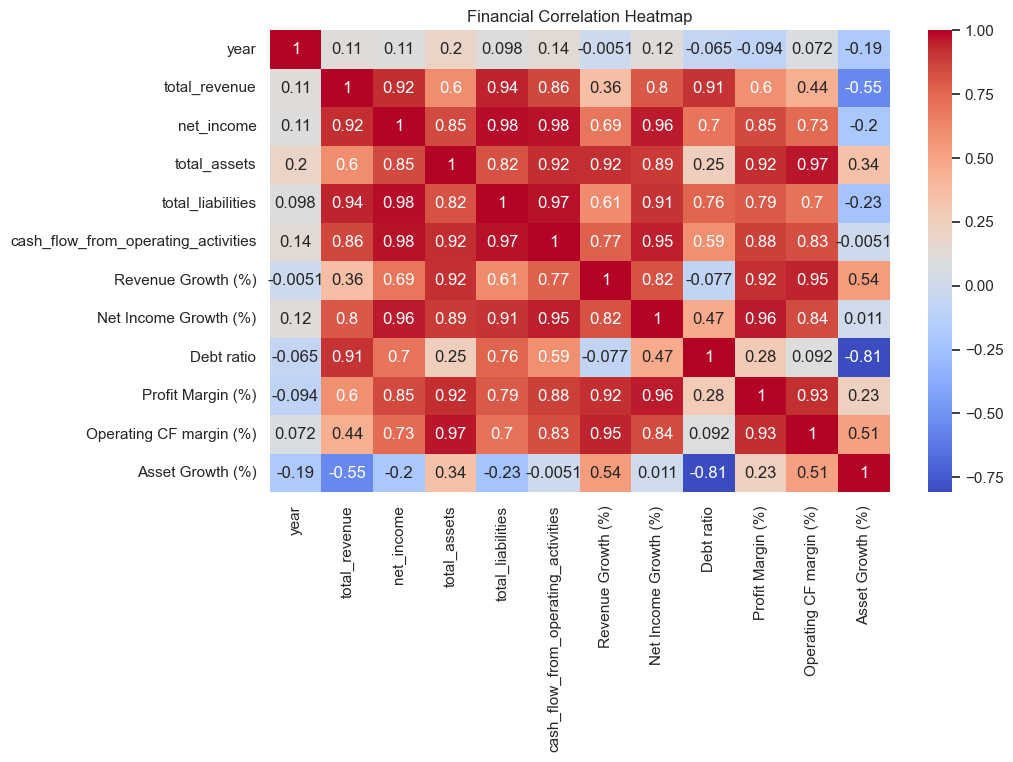

In [296]:
# Correlation Heatmap


plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Financial Correlation Heatmap")
plt.show()


**The heatmap uses colors to show how strongly two financial metrics move together.**

Red shades mean a strong positive relationship — when one metric increases, the other usually increases too.

Blue shades show a negative relationship, meaning when one metric rises, the other tends to fall. Values close to 1.0 indicate a very tight connection, while values near 0 mean little or no relationship.

You can see that net income, revenue, and operating cash flow are all deep red with each other, showing they rise and fall together in a healthy financial system. 

Debt ratio shows blue against growth and margin metrics, meaning higher debt generally reduces profitability and expansion. Metrics like revenue growth and net income growth also appear strongly red, reflecting operating leverage.

**Overall, the heatmap acts like a financial map — red clusters show strengths and alignment, while blue areas highlight pressure points or trade‑offs in the business.**

In [297]:
# save the new df afte all these creation of new features into csv

df.to_csv("finance_clean_kpis.csv", index=False)